# HPDM097 Assignment 2

## Iteration 8: New scenario (5% increased admissions) (Gemini)

This is the 8th iteration to the code. Here we created a new scenario where there is a 5% increased admission rate across all patient subgroups. A admissions_multiplier parameter was introduced to the Scenario class to accommodate for both the base and new scenarios with analysis for both to compare.

Prompt and response: https://gemini.google.com/share/45527239befe

## Prompt:
For this next step, using the same parameters and analysis for both acute beds and rehab bed capacities, I also want to compare with a separate scenario where there are 5% more admissions across all patient subgroups including the direct transfers to the rehab ward. Again use the iterative approach and build on previous code above. Ensure that the results for both the base scenario and new scenario are both calculated and displayed so we can compare for both acute stroke beds and rehab beds. Again I prefer the tables and plots and comparisons to be vertical (on top of each other) instead of side-by-side and make the plots for the new scenarios a complete separate plots as well, so essentially 4 separate stepped trade-off curves

## Response
This is a highly practical scenario. Stress-testing a system by simulating a 5% increase in demand is exactly how hospital planners determine if their current capacity is resilient or operating on a knife-edge.

To achieve this, we will add an admissions_multiplier parameter to the Scenario class. By default, it will be 1.0 (base case). For the new scenario, we will set it to 1.05. Mathematically, to increase the admission rate by 5%, we divide the mean inter-arrival times by 1.05.

We will run the simulation twice—once for the base case and once for the increased demand case—and then stack all four output tables and plots vertically as requested.

Here is the updated code:

--- Running BASE Scenario Simulation ---

--- Running +5% ADMISSIONS Scenario Simulation ---

=== BASE SCENARIO: ACUTE BEDS ===
Mean Unconstrained Occupancy: 8.17 beds
Capacity | P(delay) | % Delayed
---------------------------------
      0  |  1.0000  |  100.00%
      1  |  0.8889  |   88.89%
      2  |  0.7568  |   75.68%
      3  |  0.6574  |   65.74%
      4  |  0.6412  |   64.12%
      5  |  0.5090  |   50.90%
      6  |  0.4233  |   42.33%
      7  |  0.3285  |   32.85%
      8  |  0.2440  |   24.40%
      9  |  0.1727  |   17.27%
     10  |  0.1371  |   13.71%
     11  |  0.0817  |    8.17%
     12  |  0.0592  |    5.92%
     13  |  0.0333  |    3.33%
     14  |  0.0206  |    2.06%
     15  |  0.0091  |    0.91%
     16  |  0.0066  |    0.66%
     17  |  0.0008  |    0.08%
     18  |  0.0003  |    0.03%
     19  |  0.0005  |    0.05%
     20  |  0.0003  |    0.03%
     21  |  0.0000  |    0.00%
     22  |  0.0000  |    0.00%
     23  |  0.0000  |    0.00%
     24  |  0.0000  | 

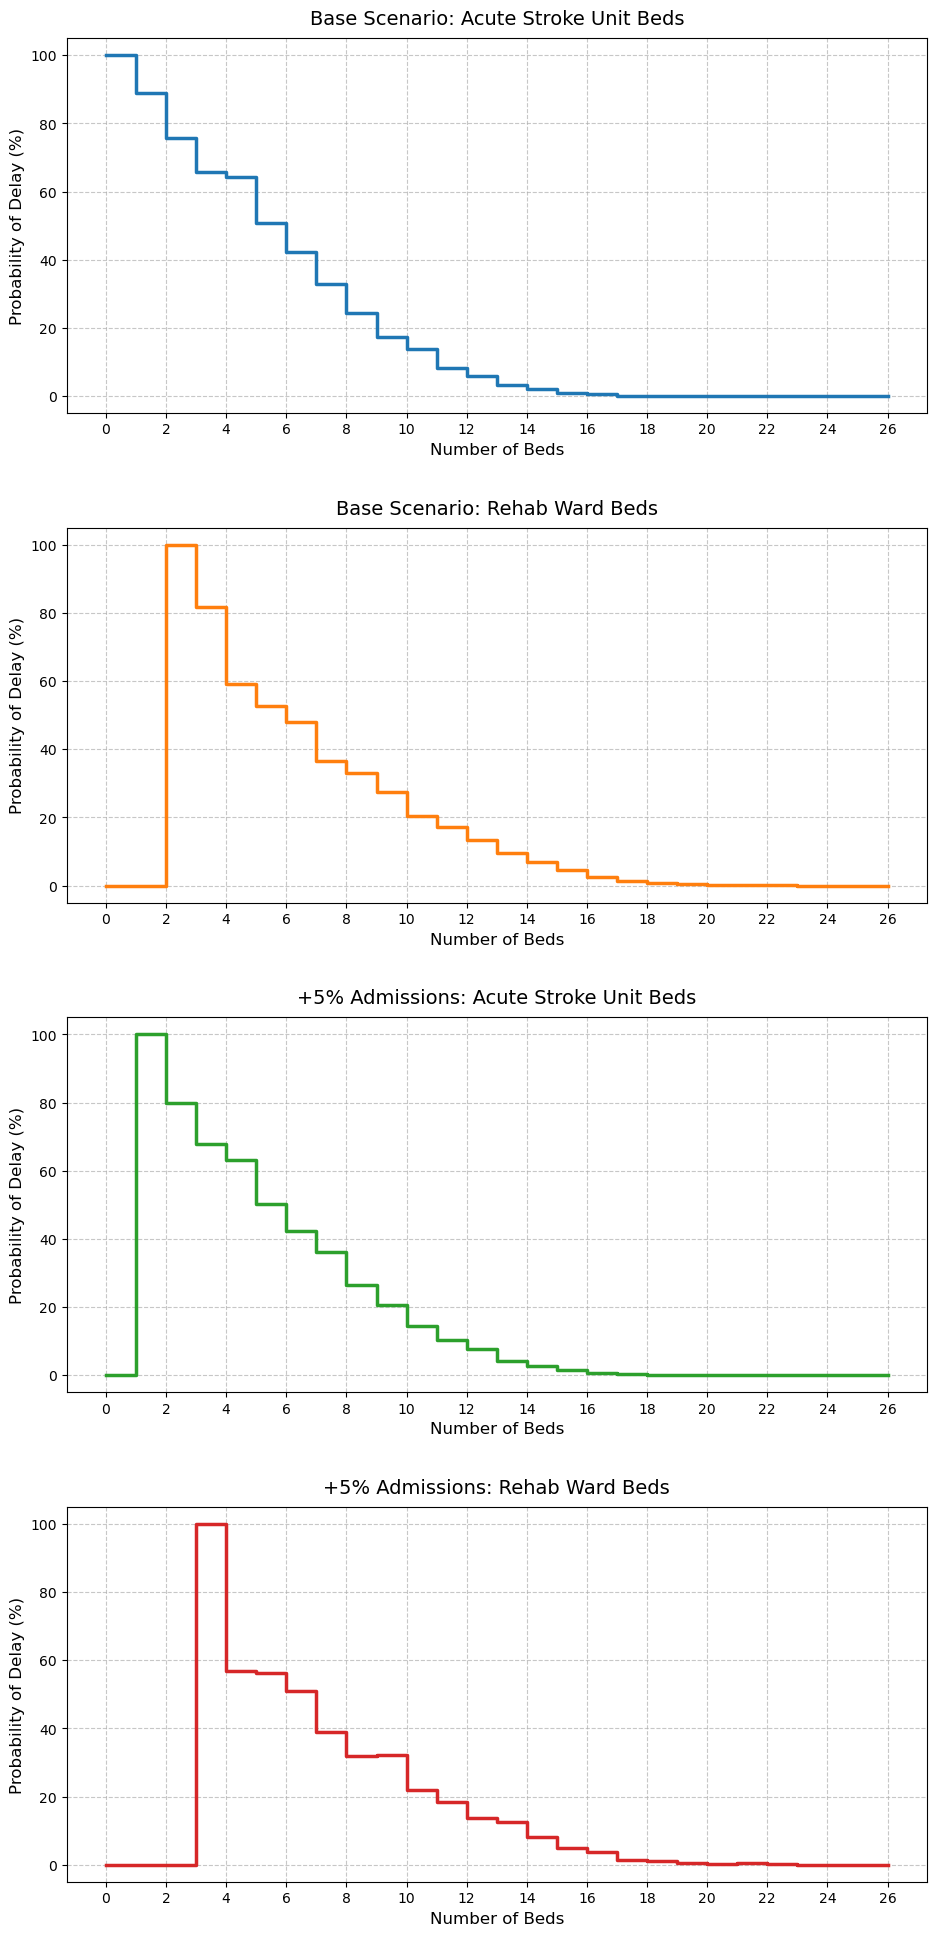

In [1]:
import simpy
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 2. Trace utility function as a debug print switch
# ---------------------------------------------------------
TRACE = False

def trace(msg):
    if TRACE:
        print(msg)

# ---------------------------------------------------------
# 1. Build and sample from distribution classes
# ---------------------------------------------------------
class ExponentialDistribution:
    def __init__(self, mean, random_seed=None):
        self.mean = mean
        self.rng = np.random.default_rng(seed=random_seed)
        
    def sample(self):
        return self.rng.exponential(scale=self.mean)

class LognormalDistribution:
    def __init__(self, sample_mean, sample_stdev, random_seed=None):
        variance = sample_stdev ** 2
        self.mu = np.log((sample_mean ** 2) / np.sqrt(variance + sample_mean ** 2))
        self.sigma = np.sqrt(np.log(1 + (variance / sample_mean ** 2)))
        self.rng = np.random.default_rng(seed=random_seed)
        
    def sample(self):
        return self.rng.lognormal(mean=self.mu, sigma=self.sigma)

# ---------------------------------------------------------
# 3. Create a parameter container class called Scenario
# ---------------------------------------------------------
class Scenario:
    def __init__(self, admissions_multiplier=1.0):
        self.random_seed = 42
        
        # Simulation Runtime Parameters (Days)
        self.warm_up_days = 3 * 365
        self.run_days = 10 * 365
        
        # Unconstrained capacities to measure offered load
        self.acute_beds_capacity = 9999 
        self.rehab_beds_capacity = 9999 
        
        # Capacities to evaluate for the trade-off curves (0 to 26)
        self.capacity_eval_range = range(0, 27) 
        
        # Apply the admissions multiplier (Rate increases = Mean Inter-arrival time decreases)
        base_acute_iat = {
            'Acute stroke': 1.2, 'TIA': 9.3, 'Complex neurological': 3.6, 'Other': 3.2
        }
        self.acute_inter_arrival_means = {
            k: v / admissions_multiplier for k, v in base_acute_iat.items()
        }
        
        base_rehab_iat = {
            'Acute stroke': 21.8, 'Complex neurological': 31.7, 'Other': 28.6
        }
        self.rehab_inter_arrival_means = {
            k: v / admissions_multiplier for k, v in base_rehab_iat.items()
        }
        
        self.acute_destinations = ['Rehab', 'ESD', 'Other']
        self.acute_transfer_matrix = {
            'Acute stroke': [0.24, 0.13, 0.63], 'TIA': [0.01, 0.01, 0.98],
            'Complex neurological': [0.11, 0.05, 0.84], 'Other': [0.05, 0.10, 0.85]
        }
        
        self.rehab_destinations = ['ESD', 'Other']
        self.rehab_transfer_matrix = {
            'Acute stroke': [0.40, 0.60], 'TIA': [0.00, 1.00],
            'Complex neurological': [0.09, 0.91], 'Other': [0.13, 0.87] 
        }
        
        self.acute_los_params = {
            'Acute stroke': {'Rehab': (7.4, 8.6), 'ESD': (4.6, 4.8), 'Other': (7.4, 8.6)},
            'TIA': {dest: (1.8, 2.3) for dest in self.acute_destinations},
            'Complex neurological': {dest: (4.0, 5.0) for dest in self.acute_destinations},
            'Other': {dest: (3.8, 5.2) for dest in self.acute_destinations}
        }
        
        self.rehab_los_params = {
            'Acute stroke': {'ESD': (30.3, 23.1), 'Other': (28.4, 27.2)},
            'TIA': {dest: (18.7, 23.5) for dest in self.rehab_destinations},
            'Complex neurological': {dest: (27.6, 28.4) for dest in self.rehab_destinations},
            'Other': {dest: (16.1, 14.1) for dest in self.rehab_destinations}
        }

# ---------------------------------------------------------
# 4. Create a patient class called AcutePatient
# ---------------------------------------------------------
class AcutePatient:
    def __init__(self, p_id, p_type, arrival_time, source="Acute"):
        self.id = p_id
        self.type = p_type
        self.arrival_time = arrival_time
        self.source = source
        self.acute_destination = None
        self.acute_bed_request_time = None
        self.acute_bed_acquire_time = None
        self.acute_length_of_stay = None
        self.acute_discharge_time = None
        self.rehab_destination = None
        self.rehab_bed_request_time = None
        self.rehab_bed_acquire_time = None
        self.rehab_length_of_stay = None
        self.rehab_discharge_time = None

# ---------------------------------------------------------
# 5. Create a model class called StrokeUnit
# ---------------------------------------------------------
class StrokeUnit:
    def __init__(self, env, scenario):
        self.env = env
        self.scenario = scenario
        self.patient_counter = 0
        
        self.daily_acute_occupancy = []
        self.daily_rehab_occupancy = []
        
        self.acute_beds = simpy.Resource(env, capacity=self.scenario.acute_beds_capacity)
        self.rehab_beds = simpy.Resource(env, capacity=self.scenario.rehab_beds_capacity)
        
        self.acute_routing_rng = np.random.default_rng(seed=self.scenario.random_seed + 100)
        self.rehab_routing_rng = np.random.default_rng(seed=self.scenario.random_seed + 200)
        
        self.acute_arrival_dists = {}
        self.rehab_arrival_dists = {}
        self.acute_los_dists = {p_type: {} for p_type in self.scenario.acute_inter_arrival_means.keys()}
        self.rehab_los_dists = {p_type: {} for p_type in self.scenario.acute_inter_arrival_means.keys()}
        
        dist_seed = self.scenario.random_seed + 1000
        
        for p_type, mean_iat in self.scenario.acute_inter_arrival_means.items():
            self.acute_arrival_dists[p_type] = ExponentialDistribution(mean_iat, dist_seed)
            dist_seed += 1
            for dest in self.scenario.acute_destinations:
                mean, stdev = self.scenario.acute_los_params[p_type][dest]
                self.acute_los_dists[p_type][dest] = LognormalDistribution(mean, stdev, dist_seed)
                dist_seed += 1
                
        for p_type, mean_iat in self.scenario.rehab_inter_arrival_means.items():
            self.rehab_arrival_dists[p_type] = ExponentialDistribution(mean_iat, dist_seed)
            dist_seed += 1
            
        for p_type in self.scenario.acute_inter_arrival_means.keys():
            for dest in self.scenario.rehab_destinations:
                mean, stdev = self.scenario.rehab_los_params[p_type][dest]
                self.rehab_los_dists[p_type][dest] = LognormalDistribution(mean, stdev, dist_seed)
                dist_seed += 1

    def daily_audit(self):
        yield self.env.timeout(self.scenario.warm_up_days)
        while True:
            self.daily_acute_occupancy.append(len(self.acute_beds.users))
            self.daily_rehab_occupancy.append(len(self.rehab_beds.users))
            yield self.env.timeout(1.0)

    def acute_arrivals_generator(self, patient_type):
        while True:
            yield self.env.timeout(self.acute_arrival_dists[patient_type].sample())
            self.patient_counter += 1
            patient = AcutePatient(self.patient_counter, patient_type, self.env.now, "Acute")
            self.env.process(self.acute_process(patient))

    def rehab_direct_arrivals_generator(self, patient_type):
        while True:
            yield self.env.timeout(self.rehab_arrival_dists[patient_type].sample())
            self.patient_counter += 1
            patient = AcutePatient(self.patient_counter, patient_type, self.env.now, "Direct Rehab")
            self.env.process(self.rehab_process(patient))

    def acute_process(self, patient):
        probs = self.scenario.acute_transfer_matrix[patient.type]
        patient.acute_destination = self.acute_routing_rng.choice(self.scenario.acute_destinations, p=probs)
        patient.acute_bed_request_time = self.env.now
        
        with self.acute_beds.request() as req:
            yield req
            patient.acute_bed_acquire_time = self.env.now
            los = self.acute_los_dists[patient.type][patient.acute_destination].sample()
            patient.acute_length_of_stay = los
            yield self.env.timeout(los)
            patient.acute_discharge_time = self.env.now
            
            if patient.acute_destination == 'Rehab':
                self.env.process(self.rehab_process(patient))

    def rehab_process(self, patient):
        probs = self.scenario.rehab_transfer_matrix[patient.type]
        patient.rehab_destination = self.rehab_routing_rng.choice(self.scenario.rehab_destinations, p=probs)
        patient.rehab_bed_request_time = self.env.now
        
        with self.rehab_beds.request() as req:
            yield req
            patient.rehab_bed_acquire_time = self.env.now
            los = self.rehab_los_dists[patient.type][patient.rehab_destination].sample()
            patient.rehab_length_of_stay = los
            yield self.env.timeout(los)
            patient.rehab_discharge_time = self.env.now

    def run_simulation(self):
        self.env.process(self.daily_audit())
        for p_type in self.scenario.acute_inter_arrival_means.keys():
            self.env.process(self.acute_arrivals_generator(p_type))
        for p_type in self.scenario.rehab_inter_arrival_means.keys():
            self.env.process(self.rehab_direct_arrivals_generator(p_type))

# =========================================================
# Analysis & Plotting Functions
# =========================================================
def calculate_p_delay_curve(occupancy_data, capacity_range):
    """Calculates Erlang P(delay) for a range of capacities based on steady-state occupancy."""
    if not occupancy_data:
        return {}
        
    max_eval_capacity = max(capacity_range)
    max_actual_occupancy = max(occupancy_data)
    array_size = max(max_eval_capacity, max_actual_occupancy) + 1
    
    counts = np.zeros(array_size)
    for occ in occupancy_data:
        counts[occ] += 1
        
    pdf = counts / len(occupancy_data)
    cdf = np.cumsum(pdf)
    
    results = {}
    for n in capacity_range:
        p_n = pdf[n]
        p_le_n = cdf[n]
        p_delay = p_n / p_le_n if p_le_n > 0 else 0.0
        results[n] = p_delay
        
    return results

def print_table(title, occupancy_data, results):
    """Utility to print a cleanly formatted table vertically."""
    print(f"\n{title}")
    print(f"Mean Unconstrained Occupancy: {np.mean(occupancy_data):.2f} beds")
    print("Capacity | P(delay) | % Delayed")
    print("---------------------------------")
    for beds, p_delay in results.items():
        print(f" {beds:6d}  |  {p_delay:.4f}  | {p_delay*100:7.2f}%")

def plot_four_tradeoff_curves(base_acute, base_rehab, inc_acute, inc_rehab):
    """Generates a vertically stacked plot of all four P(delay) curves."""
    beds = list(base_acute.keys())
    
    fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(10, 20))
    
    datasets = [
        (base_acute, 'Base Scenario: Acute Stroke Unit Beds', '#1f77b4'),
        (base_rehab, 'Base Scenario: Rehab Ward Beds', '#ff7f0e'),
        (inc_acute, '+5% Admissions: Acute Stroke Unit Beds', '#2ca02c'),
        (inc_rehab, '+5% Admissions: Rehab Ward Beds', '#d62728')
    ]
    
    for ax, (data_dict, title, color) in zip(axes, datasets):
        p_delay_pct = [val * 100 for val in data_dict.values()]
        ax.step(beds, p_delay_pct, where='post', color=color, linewidth=2.5)
        ax.set_title(title, fontsize=14, pad=10)
        ax.set_xlabel('Number of Beds', fontsize=12)
        ax.set_ylabel('Probability of Delay (%)', fontsize=12)
        ax.grid(True, linestyle='--', alpha=0.7)
        ax.set_xticks(beds[::2])
        ax.set_ylim(-5, 105)
        
    plt.tight_layout(pad=3.0)
    plt.show()

# =========================================================
# Execution
# =========================================================
if __name__ == "__main__":
    # 1. Run Base Scenario
    print("--- Running BASE Scenario Simulation ---")
    base_scenario = Scenario(admissions_multiplier=1.0)
    env_base = simpy.Environment()
    model_base = StrokeUnit(env_base, base_scenario)
    model_base.run_simulation()
    env_base.run(until=base_scenario.warm_up_days + base_scenario.run_days)
    
    base_acute_results = calculate_p_delay_curve(model_base.daily_acute_occupancy, base_scenario.capacity_eval_range)
    base_rehab_results = calculate_p_delay_curve(model_base.daily_rehab_occupancy, base_scenario.capacity_eval_range)

    # 2. Run +5% Scenario
    print("\n--- Running +5% ADMISSIONS Scenario Simulation ---")
    inc_scenario = Scenario(admissions_multiplier=1.05)
    env_inc = simpy.Environment()
    model_inc = StrokeUnit(env_inc, inc_scenario)
    model_inc.run_simulation()
    env_inc.run(until=inc_scenario.warm_up_days + inc_scenario.run_days)
    
    inc_acute_results = calculate_p_delay_curve(model_inc.daily_acute_occupancy, inc_scenario.capacity_eval_range)
    inc_rehab_results = calculate_p_delay_curve(model_inc.daily_rehab_occupancy, inc_scenario.capacity_eval_range)

    # 3. Print Vertically Stacked Tables
    print_table("=== BASE SCENARIO: ACUTE BEDS ===", model_base.daily_acute_occupancy, base_acute_results)
    print_table("=== BASE SCENARIO: REHAB BEDS ===", model_base.daily_rehab_occupancy, base_rehab_results)
    print_table("=== +5% ADMISSIONS: ACUTE BEDS ===", model_inc.daily_acute_occupancy, inc_acute_results)
    print_table("=== +5% ADMISSIONS: REHAB BEDS ===", model_inc.daily_rehab_occupancy, inc_rehab_results)

    # 4. Generate the 4-Pane Plot
    print("\nGenerating Matplotlib visualization...")
    plot_four_tradeoff_curves(base_acute_results, base_rehab_results, inc_acute_results, inc_rehab_results)